In [1]:
!pip install -q kaggle

In [2]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 95.4MB/s]



In [3]:
!unzip sms-spam-collection-dataset.zip

Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                


In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# remove last 3 columns
df = df.drop(df.columns[2:], axis=1)
df.sample(5)

,v1,v2
4360,ham,"Don't Think About \What u Have Got\"" Think Abo..."
2907,ham,Why must we sit around and wait for summer day...
2474,ham,"Princess, i like to make love &lt;#&gt; time..."
4210,ham,Oi when you gonna ring
4573,ham,:( but your not here....


In [7]:
# meaningful column hearder names
df.columns = ['label', 'text']
df.sample(5)


,label,text
2378,ham,"Hi, Mobile no. &lt;#&gt; has added you in th..."
50,ham,What you thinked about me. First time you saw ...
1172,ham,Happy new years melody!
1429,spam,For sale - arsenal dartboard. Good condition b...
4184,ham,I'm good. Have you registered to vote?


In [8]:
# perfrom label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
df.sample(5)

,label,text
2204,0,Raji..pls do me a favour. Pls convey my Birthd...
2009,0,I can't keep going through this. It was never ...
3303,0,IM GONNAMISSU SO MUCH!!I WOULD SAY IL SEND U A...
1730,0,Doing project w frens lor.
5411,0,I ask if u meeting da ge tmr nite...


In [9]:
# check for missing values
df.isnull().sum()

,0
label,0
text,0


In [10]:
# check for duplicates values and remove it
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

In [11]:
# class distribution analysis
df['label'].value_counts()


,count
label,
0,4516
1,653


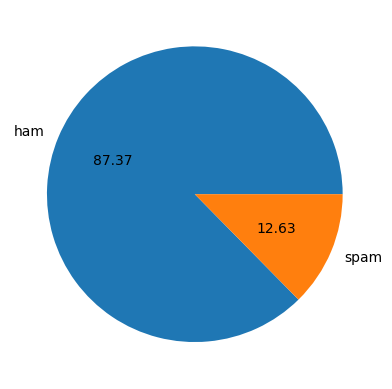

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.pie(df['label'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

### Imbalanced data can effect model performance

In [13]:
!pip install nltk

In [14]:
import nltk

In [15]:
nltk.download('punkt') # punkt is pre-trained, unsupervised machine learning model used to detect sentence boundary.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [16]:
# create column to store the num_characters in sentences
df['num_characters'] = df['text'].apply(len)
df.sample(5)


,label,text,num_characters
1203,0,Thanks for understanding. I've been trying to ...,61
3935,0,They r giving a second chance to rahul dengra.,46
4576,1,Had your contract mobile 11 Mnths? Latest Moto...,159
4997,0,Can you talk with me..,22
3562,1,Auction round 4. The highest bid is now å£54. ...,133


In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
# create column to store the num_words in sentences
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.sample(5)

,label,text,num_characters,num_words
5330,0,Dude im no longer a pisces. Im an aquarius now.,47,12
4401,0,Good FRIENDS CaRE for each Other.. CLoSE Frien...,138,26
3187,1,This is the 2nd time we have tried 2 contact u...,153,34
5441,0,"By the way, make sure u get train to worc fore...",90,21
3760,0,Was just about to ask. Will keep this one. May...,110,27


In [19]:
# create column to store the num_sentences for each entry
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.sample(5)

,label,text,num_characters,num_words,num_sentences
5248,0,U come n search tat vid..not finishd..,38,10,1
1108,0,No you'll just get a headache trying to figure...,101,29,4
4131,0,Hi baby ive just got back from work and i was ...,147,38,3
2486,0,I dont thnk its a wrong calling between us,42,9,1
1802,0,Ok lor thanx... ÌÏ in school?,29,8,1


In [20]:
# descriptive statistics on newly derived features
df[2:].describe()

,label,num_characters,num_words,num_sentences
count,5167.000000,5167.000000,5167.000000,5167.000000
mean,0.126379,78.981421,18.456745,1.965551
std,0.332308,58.241710,13.326320,1.448822
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


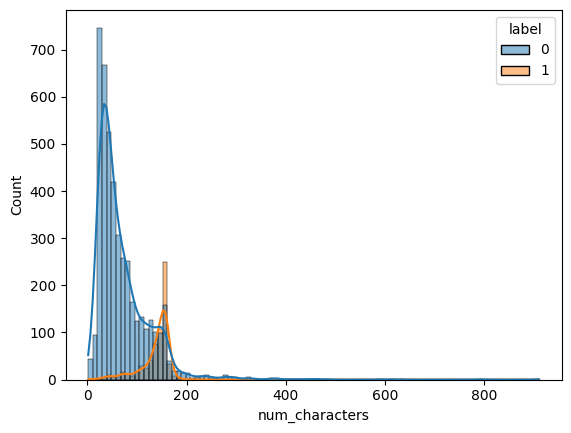

In [21]:
# plot combined histogram for different classes in label column for descriptive statistics
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='num_characters', hue='label', kde=True)
plt.show()

# Data Preprocessing

In [22]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
# create a function 'transform_text' to perform data preprocessing
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
  # transform text to lower case
  text = text.lower()

  # text tokenization
  text = nltk.word_tokenize(text)

  # remove special characters from the tokenized text
  text = [word for word in text if word.isalnum()]

  # remove stopwords and punctuations
  for word in text:
    if word in stopwords.words('english') or word in string.punctuation:
      text.remove(word)

  # perform stemming
  text = [ps.stem(word) for word in text]

  return  ' '.join(text)

In [24]:
# create a column transform_text to store the text after data proprocessing
df['transform_text'] = df['text'].apply(transform_text)
df.sample(5)

,label,text,num_characters,num_words,num_sentences,transform_text
3361,0,No messages on her phone. I'm holding it now,44,11,2,messag her phone hold now
1282,0,Ever green quote ever told by Jerry in cartoon...,160,42,2,ever green quot ever told jerri cartoon person...
781,0,"Hmmm ... I thought we said 2 hours slave, not ...",94,23,2,hmmm thought said 2 hour slave 3 are late shou...
3109,1,Good Luck! Draw takes place 28th Feb 06. Good ...,112,22,4,good luck draw take place 28th feb good luck r...
3705,0,Reading gud habit.. Nan bari hudgi yorge patai...,65,14,1,read gud habit nan bari hudgi yorg pataistha e...


In [25]:
# create word cloud for different classes of label feature
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

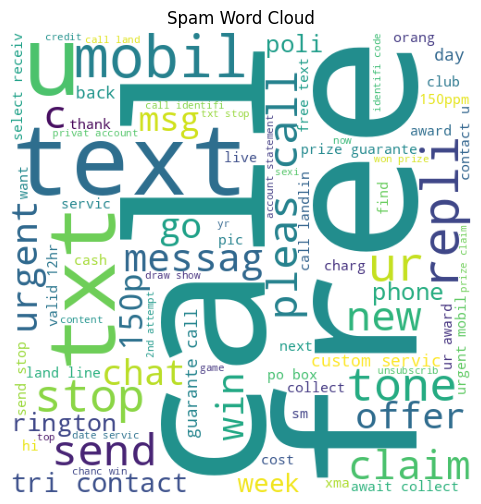

In [26]:
spam_wc = wc.generate(df[df['label']==1]['transform_text'].str.cat(sep=' '))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.title('Spam Word Cloud')
plt.axis('off')
plt.show()

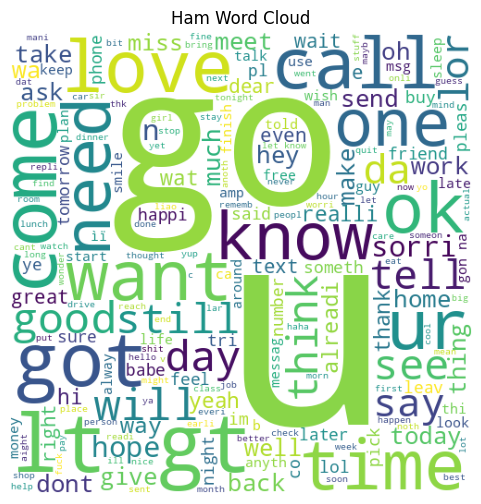

In [27]:
ham_wc = wc.generate(df[df['label']==0]['transform_text'].str.cat(sep=' '))

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.title('Ham Word Cloud')
plt.axis('off')
plt.show()

In [28]:
# extract top 30 words from the tranformed_text for each class in label feature
spam_corpus = []
for msg in df[df['label']==1]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

ham_corpus = []
for msg in df[df['label']==0]['transform_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)


In [29]:
from collections import Counter
spam_counter = Counter(spam_corpus)
ham_counter = Counter(ham_corpus)

spam_top_30 = dict(spam_counter.most_common(30))
ham_top_30 = dict(ham_counter.most_common(30))

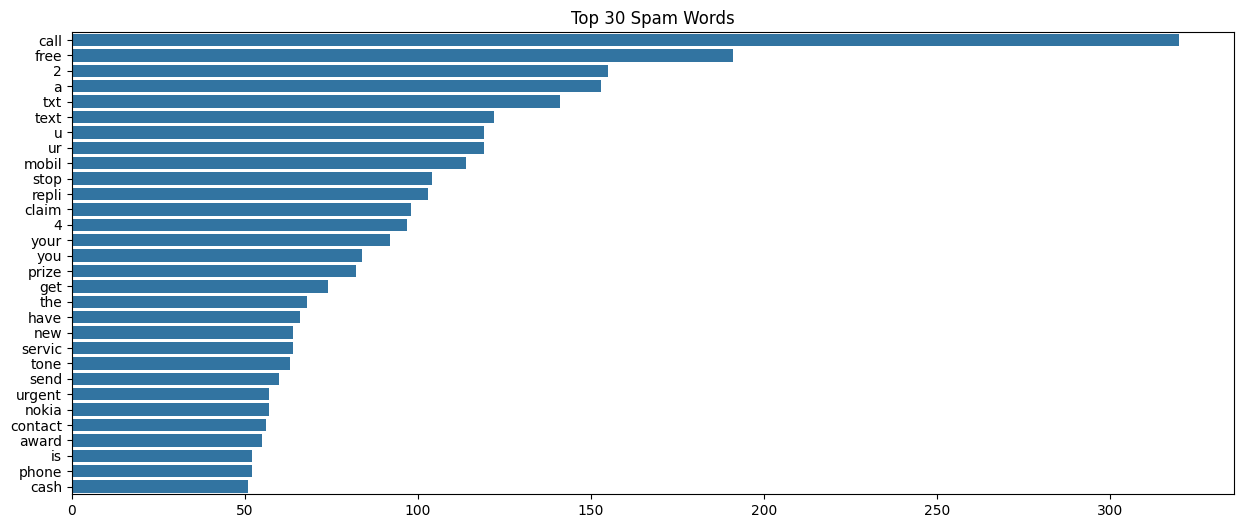

In [30]:
# create a bar plot (use different colors) for top spam words
plt.figure(figsize=(15,6))
sns.barplot(x=list(spam_top_30.values()), y=list(spam_top_30.keys()))
plt.title('Top 30 Spam Words')
plt.show()

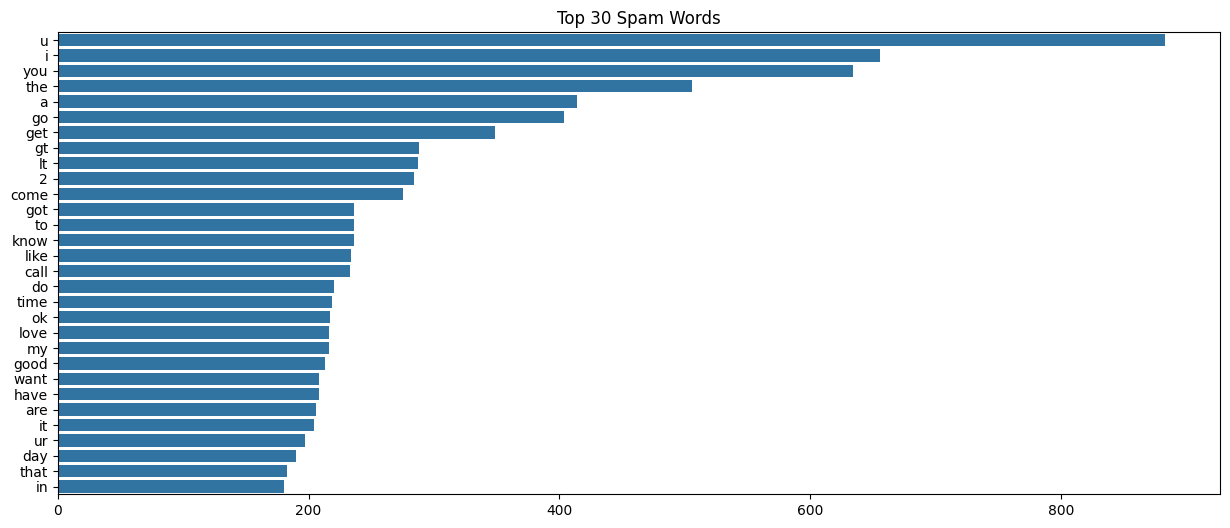

In [31]:
# create a bar plot for top ham words
plt.figure(figsize=(15,6))
sns.barplot(x=list(ham_top_30.values()), y=list(ham_top_30.keys()))
plt.title('Top 30 Spam Words')
plt.show()

# Model Building

### Vectorized text using bag-of-words

In [32]:
# vectorize the transformed_text feature using bag-of-words
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

X = cv.fit_transform(df['transform_text']).toarray()
y = df['label'].values

In [33]:
# apply train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [34]:
# train the model using Navie-Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)

In [35]:
# print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       896
           1       0.84      0.91      0.88       138

    accuracy                           0.97      1034
   macro avg       0.91      0.94      0.93      1034
weighted avg       0.97      0.97      0.97      1034



### Vectorized text using TF-IDF

In [36]:
# vectorize the transformed_text feature using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transform_text']).toarray()
y = df['label'].values

In [37]:
# apply train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [38]:
# train the model using Navie-Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)

In [39]:
# print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       1.00      0.79      0.88       138

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



## Oversampling

### Smoothed Bootstrap Oversampling

In [40]:
!pip install -q imblearn

In [41]:
# apply smoothed bootstrap oversampling technique to balanced the dataset
from imblearn.over_sampling import SVMSMOTE

smote = SVMSMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Shape of X before oversampling: {X.shape}")
print(f"Shape of y before oversampling: {y.shape}")
print(f"Shape of X after oversampling: {X_resampled.shape}")
print(f"Shape of y after oversampling: {y_resampled.shape}")

Shape of X before oversampling: (5169, 3000)
Shape of y before oversampling: (5169,)
Shape of X after oversampling: (9032, 3000)
Shape of y after oversampling: (9032,)


In [45]:
import pandas as pd

y_resampled_series = pd.Series(y_resampled)
print(y_resampled_series.value_counts())

0    4516
1    4516
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=2)

In [48]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
import numpy as np # Import numpy for clipping values

mnb = MultinomialNB()
mnb.fit(np.maximum(0, X_train), y_train)
y_pred = mnb.predict(X_test)

In [49]:
# print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       906
           1       0.98      0.98      0.98       901

    accuracy                           0.98      1807
   macro avg       0.98      0.98      0.98      1807
weighted avg       0.98      0.98      0.98      1807



In [50]:
import joblib

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

joblib.dump(mnb, 'mnb_model.pkl')

['mnb_model.pkl']